# ** 5. Comparison of temporal evolution in the CR and EC regimes ** 
** This routine concerns figure 5 to 11 and tables 3 and 4 from section 5 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the time series

In [2]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'
filename_nusselt_pr3 = './data_from_dns/nusselt_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'
filename_nusselt_pr43 = './data_from_dns/nusselt_50000000_4.3_512_060to259.h5'

In [3]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
nus_pr3 = pd.read_hdf(filename_nusselt_pr3)
POD_pr3 = pd.read_hdf(filename_modes_pr3)

POD_pr3['f']=POD_pr3['k1'].abs()
scale_pr3 = POD_pr3.mean()['f']

pod_pr3 = POD_pr3[['k1','k2','k3','k4','k5','k6','f']]/POD_pr3.mean()['f']
pod_pr3['t'] = glb_pr3.t
pod_pr3['CRregime'] = glb_pr3.CRregime

thres_pr3=glb_pr3.mean()['f'] + glb_pr3.std()['f']

In [4]:
glb_pr43 = pd.read_hdf(filename_global_pr43)
nus_pr43 = pd.read_hdf(filename_nusselt_pr43)
POD_pr43 = pd.read_hdf(filename_modes_pr43)

POD_pr43['f']=POD_pr43['k1'].abs()
scale_pr43 = POD_pr43.mean()['f']
pod_pr43 = POD_pr43[['k1','k2','k3','k4','k5','k6','f']]/POD_pr43.mean()['f']
pod_pr43['t'] = glb_pr43.t
pod_pr43['k4'] = -pod_pr43.k4
pod_pr43['CRregime'] = glb_pr43.CRregime

thres_pr43=glb_pr43.mean()['f'] + glb_pr43.std()['f']

## 2. Temporal evolution of the modal coefficients

Let us project the primitive fields $\vec{\psi(\vec{x}, t)}$ into the set of POD modes extracted from the CR regime to obtain the modal amplitudes 
$\alpha_k(t)$.

### 2.1 Plot the time evolution fo the modal coefficients (figure 5)

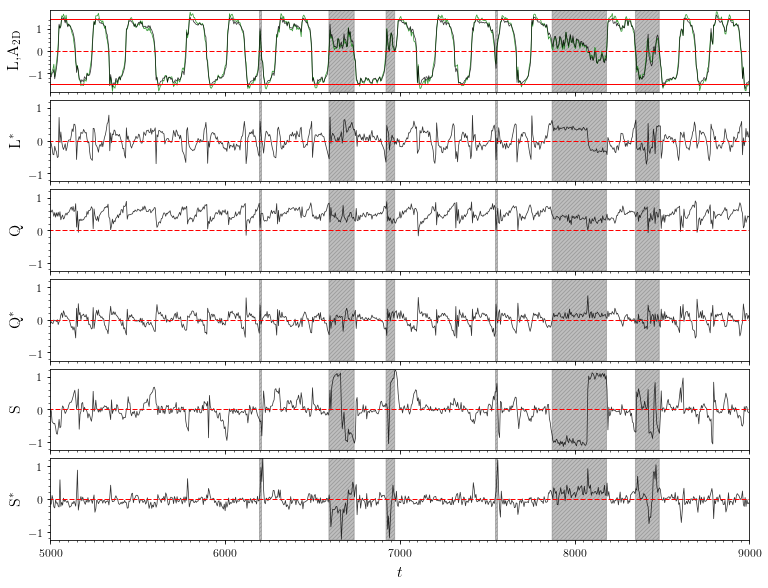

In [5]:
import matplotlib.transforms as mtransforms
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

plt.rcParams['figure.figsize'] = (10.5, 8.0)
f, axes = plt.subplots(6, 1, sharey=False, sharex=True)
ax= np.ravel(axes)

majorLocator_y = MultipleLocator(1.0)
minorLocator_y = MultipleLocator(0.2)
labels = ['$\mathrm{L}$,$\mathrm{A_{2D}}$','$\mathrm{L}^*$','$\mathrm{Q}$','$\mathrm{Q}^*$','$\mathrm{S}$','$\mathrm{S}^*$']

skip=100

i=0
glb_pr43.iloc[::skip, :].plot(x='t', y='l2d', lw=0.75, c='g', alpha=0.8, legend=False, xlim=[1500,5500], ax=ax[0], rasterized=True);
for k in ['k1','k4','k2','k5','k3','k6']:
    pod_pr43.iloc[::skip, :].plot(x='t', y=k,  lw=0.75, c='k', alpha=0.8, legend=False, xlim=[5000,9000], ylim=[-1.25,1.25], ax=ax[i], rasterized=True);
    trans = mtransforms.blended_transform_factory(ax[i].transData, ax[i].transAxes)
    ax[i].fill_between(pod_pr43.t, 0, 1, where=pod_pr43.CRregime == False, color='gray',facecolor='gray', hatch = '//////', alpha=0.5, transform=trans, rasterized=True)
    ax[i].plot((0,9000),(0,0),'red',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_major_locator(majorLocator_y)
    ax[i].yaxis.set_minor_locator(minorLocator_y)
    i= i+1 

ax[0].set_ylim([-1.85,1.85])

ax[0].axhline(y=thres_pr43,color='red',linewidth=1.0)
ax[0].axhline(y=-thres_pr43,color='red',linewidth=1.0)

majorLocator_x = MultipleLocator(1000)
minorLocator_x = MultipleLocator(50)
ax[5].xaxis.set_major_locator(majorLocator_x)
ax[5].xaxis.set_minor_locator(minorLocator_x)
ax[5].set_xlabel('$t$')
    
plt.tight_layout(pad=0.1) 
plt.savefig('figures_for_article/figure5a.pdf',dpi=150)

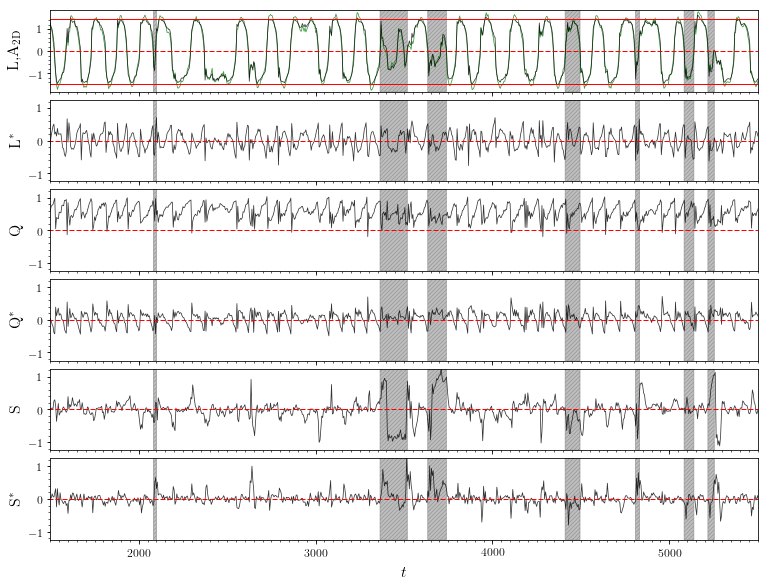

In [6]:
f, axes = plt.subplots(6, 1, sharey=False, sharex=True)
ax= np.ravel(axes)

majorLocator_y = MultipleLocator(1.0)
minorLocator_y = MultipleLocator(0.2)
labels = ['$\mathrm{L}$,$\mathrm{A_{2D}}$','$\mathrm{L}^*$','$\mathrm{Q}$','$\mathrm{Q}^*$','$\mathrm{S}$','$\mathrm{S}^*$']

i=0
skip=100
glb_pr3.iloc[::skip, :].plot(x='t', y='l2d', lw=0.75, c='g', alpha=0.8, legend=False, xlim=[1500,5500], ax=ax[0], rasterized=True);
for k in ['k1','k3','k2','k5','k4','k6']:
    pod_pr3.iloc[::skip, :].plot(x='t', y=k,  lw=0.75, c='k', alpha=0.8, legend=False, xlim=[1500,5500], ylim=[-1.25,1.25], ax=ax[i], rasterized=True);
    trans = mtransforms.blended_transform_factory(ax[i].transData, ax[i].transAxes)
    ax[i].fill_between(glb_pr3.t, 0, 1, where=glb_pr3.CRregime == False, color='gray',facecolor='gray', hatch = '//////', alpha=0.5, transform=trans, rasterized=True)
    ax[i].plot((0,8000),(0,0),'red',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_major_locator(majorLocator_y)
    ax[i].yaxis.set_minor_locator(minorLocator_y)
    i= i+1 
    
ax[0].axhline(y=thres_pr3,color='red',linewidth=1.0)
ax[0].axhline(y=-thres_pr3,color='red',linewidth=1.0)
    
ax[0].set_ylim([-1.85,1.85])

majorLocator_x = MultipleLocator(1000)
minorLocator_x = MultipleLocator(50)
ax[5].xaxis.set_major_locator(majorLocator_x)
ax[5].xaxis.set_minor_locator(minorLocator_x)
ax[5].set_xlabel('$t$')
    
plt.tight_layout(pad=0.1) 
plt.savefig('figures_for_article/figure5b.pdf',dpi=150)

### 2.2 Plot the PDFs of the modal coefficients (figure 6)

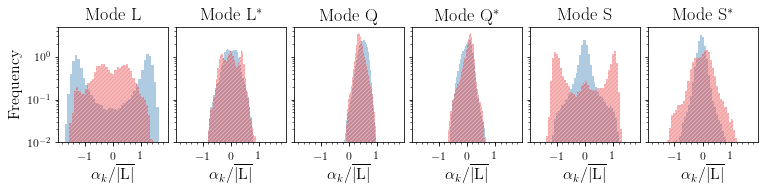

In [7]:
plt.rcParams['figure.figsize'] = (10.5, 2.5)

f, axes = plt.subplots(1, 6, sharey=True, sharex=True)
ax= np.ravel(axes)

labels = ['Mode $\mathrm{L}$','Mode $\mathrm{L}^*$','Mode $\mathrm{Q}$','Mode $\mathrm{Q}^*$','Mode $\mathrm{S}$','Mode $\mathrm{S}^*$']
majorLocator_x = MultipleLocator(1.0)
minorLocator_x = MultipleLocator(0.2)

i=0
for k in ['k1','k4','k2','k5','k3','k6']:
    pod_pr43[k].loc[pod_pr43.CRregime==True].plot.hist(ax=ax[i], bins=40,linewidth=0., alpha=0.4, color='#377eb8', density=True, log=True, ylim=[0.01,5], rasterized=True);
    pod_pr43[k].loc[pod_pr43.CRregime==False].plot.hist(ax=ax[i],bins=40,linewidth=0., alpha=0.4, edgecolor='w', facecolor='#e41a1c', hatch = '//////',density=True, log=True, ylim=[0.01,5], rasterized=True);
   
    ax[i].set_title(labels[i], fontsize=18)
    ax[i].set_yscale('log')
    ax[i].set_ylim([0.01,5])
    ax[i].set_xlim([-1.95,1.95])
    ax[i].set_xlabel('$\\alpha_k/\\overline{\\vert\\mathrm{L}\\vert}$')
    ax[i].xaxis.set_major_locator(majorLocator_x)
    ax[i].xaxis.set_minor_locator(minorLocator_x)
    i=i+1

plt.tight_layout(pad=0.1) 
plt.savefig('figures_for_article/figure6a.pdf',dpi=200)

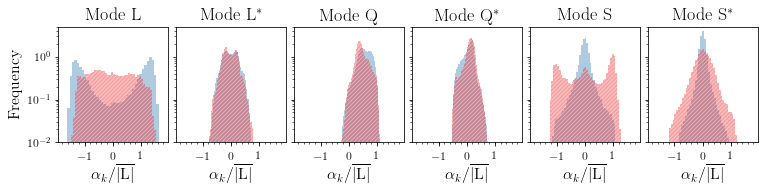

In [8]:
plt.rcParams['figure.figsize'] = (10.5, 2.5)

f, axes = plt.subplots(1, 6, sharey=True, sharex=True)
ax= np.ravel(axes)

labels = ['Mode $\mathrm{L}$','Mode $\mathrm{L}^*$','Mode $\mathrm{Q}$','Mode $\mathrm{Q}^*$','Mode $\mathrm{S}$','Mode $\mathrm{S}^*$']
majorLocator_x = MultipleLocator(1.0)
minorLocator_x = MultipleLocator(0.2)

i=0
for k in ['k1','k3','k2','k5','k4','k6']:
    pod_pr3[k].loc[pod_pr3.CRregime==True].plot.hist(ax=ax[i], bins=40,linewidth=0., alpha=0.4, color='#377eb8', density=True, log=True, ylim=[0.01,5], rasterized=True);
    pod_pr3[k].loc[pod_pr3.CRregime==False].plot.hist(ax=ax[i],bins=40,linewidth=0., alpha=0.4, edgecolor='w', facecolor='#e41a1c', hatch = '//////',density=True, log=True, ylim=[0.01,5], rasterized=True);
   
    ax[i].set_title(labels[i], fontsize=18)
    ax[i].set_yscale('log')
    ax[i].set_ylim([0.01,5])
    ax[i].set_xlim([-1.95,1.95])
    ax[i].set_xlabel('$\\alpha_k/\\overline{\\vert\\mathrm{L}\\vert}$')
    ax[i].xaxis.set_major_locator(majorLocator_x)
    ax[i].xaxis.set_minor_locator(minorLocator_x)
    i=i+1

plt.tight_layout(pad=0.1) 
plt.savefig('figures_for_article/figure6b.pdf',dpi=300)

## 3. Probability distribution of the waiting times for reversing POD modes

If the set of amplitudes $M(t)\equiv(L, L^∗, Q, Q^∗, S, S^∗)$ corresponds to a solution of the governing equations, then $\mathbb{S}_x M$, $\mathbb{S}_y M$, and $\mathrm{R}_\pi M$ are also sets associated to a solution of
these equations. Applying these operators reveals that modes L and L$^*$ are changed into their opposite by $\mathbb{S}_x$ and $\mathbb{S}_y$, idem for mode S under $\mathbb{S}_x$ and $\mathrm{R}_\pi$, and for mode S$^*$ under $\mathbb{S}_y$ and $\mathrm{R}_\pi$. Consequently, such POD modes may exhibit a reversing dynamics, unlike the modes Q and Q$^∗$ which do not reverse. In order to elucidate the nature of the process
generating the reversal events, we focus on the time interval $\tau$ (also known as the waiting time) between consecutive changes of sign of these reversing modes.

To verify whether or not the independence hypothesis is correct,
the probability distribution of the waiting time $\tau$ is compared to a Gamma distribution

$$ \mathrm{PDF}(\tau_\mathrm{M}) = \left(\frac{k}{m}\right)^k \frac{\tau_\mathrm{M}^{k-1}}{\Gamma(k)} \exp{\left(-k\frac{\tau_\mathrm{M}}{m}\right)}, \mbox{ with } \Gamma(k) = \int_0^\infty x^{k-1} \exp{(-x)} dx $$

where $\Gamma(k)$ is the Gamma function, $k$ the shape parameter, and $m$ the expected mean value of $\tau_\mathrm{M}$.

### 3.1 Compute the waiting times for the reversing modes

In [9]:
def crossings(x,y,z,c):
    x0 = pd.DataFrame() 
   
    n = y.shape[0]
    index = np.where((y[0:n-2]-c)*(y[1:n-1]-c) < 0)
    index = np.asarray(index)
    index = index.T[:,0]
    m = index.shape[0]
    
    x0['ti'] = x[index.T[0:m-1]]
    x0['tm'] = 0.5*(x[index.T[0:m-1]] + x[index.T[1:m]])
    x0['tf'] = x[index.T[1:m]]
    x0['tau'] = x0['tf'] - x0['ti']
    midpoint = (index.T[1:m]-index.T[0:m-1])/2 + index.T[0:m-1]    
    x0['tm'] = x[midpoint.astype(int)]    
    
    x0['idxi'] = index.T[0:m-1]
    x0['idxf'] = index.T[1:m]
    
    c = np.zeros((m-1,))    
    for n in range(0, m-1):
        a = np.max(z[np.arange(index.T[n],index.T[n+1])])
        b = np.min(z[np.arange(index.T[n],index.T[n+1])])
        c[n] = a if a>-b else b        
        
    x0['ymax'] = c
    return x0, index.T;

def amplitude_filter2(zero,cr): 
    nrev=zero.shape
    c=np.zeros((nrev[0]),dtype=bool)
    for nr in range(0, nrev[0]-1):
        c[nr] = np.any(np.equal((cr.t > zero.ti.values[nr]) , (cr.t <= zero.tf.values[nr])))
    zero['isrev'] = c
    return zero ; 

zero1_pr43, _ = np.array(crossings(pod_pr43.t.values, pod_pr43.k1.values, pod_pr43.k1.values,0.))
zero2_pr43, _ = np.array(crossings(pod_pr43.t.values, pod_pr43.k4.values, pod_pr43.k1.values,0.))
zero3_pr43, _ = np.array(crossings(pod_pr43.t.values, pod_pr43.k3.values, pod_pr43.k1.values,0.))
zero4_pr43, _ = np.array(crossings(pod_pr43.t.values, pod_pr43.k6.values, pod_pr43.k1.values,0.))

cr=glb_pr43.loc[glb_pr43.CRregime==True]
zero1_pr43 = amplitude_filter2(zero1_pr43,cr)
zero2_pr43 = amplitude_filter2(zero2_pr43,cr)
zero3_pr43 = amplitude_filter2(zero3_pr43,cr)
zero4_pr43 = amplitude_filter2(zero4_pr43,cr)

zero1_pr3, _ = np.array(crossings(pod_pr3.t.values, pod_pr3.k1.values, pod_pr3.k1.values,0.))
zero2_pr3, _ = np.array(crossings(pod_pr3.t.values, pod_pr3.k3.values, pod_pr3.k1.values,0.))
zero3_pr3, _ = np.array(crossings(pod_pr3.t.values, pod_pr3.k4.values, pod_pr3.k1.values,0.))
zero4_pr3, _ = np.array(crossings(pod_pr3.t.values, pod_pr3.k6.values, pod_pr3.k1.values,0.))

cr=glb_pr3.loc[glb_pr3.CRregime==True]
zero1_pr3 = amplitude_filter2(zero1_pr3,cr)
zero2_pr3 = amplitude_filter2(zero2_pr3,cr)
zero3_pr3 = amplitude_filter2(zero3_pr3,cr)
zero4_pr3 = amplitude_filter2(zero4_pr3,cr)

In [10]:
zero1_pr43.to_hdf('./results_from_waiting_times/zero1_pr43.h5', key='s')
zero1_pr3.to_hdf('./results_from_waiting_times/zero1_pr3.h5', key='s')

zero2_pr43.to_hdf('./results_from_waiting_times/zero2_pr43.h5', key='s')
zero2_pr3.to_hdf('./results_from_waiting_times/zero2_pr3.h5', key='s')

zero3_pr43.to_hdf('./results_from_waiting_times/zero3_pr43.h5', key='s')
zero3_pr3.to_hdf('./results_from_waiting_times/zero3_pr3.h5', key='s')

zero4_pr43.to_hdf('./results_from_waiting_times/zero4_pr43.h5', key='s')
zero4_pr3.to_hdf('./results_from_waiting_times/zero4_pr3.h5', key='s')

### 3.2 Fit the distributions to either a Poisson or a Gamma distribution
(figures 7 and 8 and tables 3 and 4)

In [11]:
from scipy.optimize import curve_fit
from scipy.stats import gamma, expon
bins=np.arange(0.0,400,2.5)

def func(x, a, b):
    return gamma.pdf(x, a, 0.0, b) 

def get_fit(x,shape,loc,scale):
    bins=np.arange(0.0,400,2.5)
    a,b = np.histogram(x,bins,density=True)
    c = 0.5*(b[:-1]+b[1:])    
    popt, pcov = curve_fit(func, c, a, p0=(shape,scale))
    perr = np.sqrt(np.diag(pcov))
    
    return popt[0], popt[1], perr ;

def get_rms(x,shape,scale):
    loc=0.0
    a,b = np.histogram(x,bins,density=True)
    c = 0.5*(b[:-1]+b[1:])    
    d = np.sum(np.power(a-gamma.pdf(c, shape, loc, scale),2.0))
    e = np.sum(np.power(a-np.mean(a),2.0))
    f = 1-d/e
    return f ;

def get_poisson_fits(zero,tau2):
    
    shape=1

    loc, scale = expon.fit(zero.tau, floc=0)    
    r2 = get_rms(zero.tau, shape, scale)
    n = zero.tau.count()
    fitted = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    
    s = gamma.pdf(tau2, shape, loc, scale)
    c = gamma.sf(tau2, shape, loc, scale)
        
    loc, scale = expon.fit(zero.loc[zero.isrev==True].tau, floc=0)
    r2 = get_rms(zero.loc[zero.isrev==True].tau,shape,scale)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    
    s_cr = gamma.pdf(tau2, shape, loc, scale)    
    c_cr = gamma.sf(tau2, shape, loc, scale)/scale    
    
    loc, scale = expon.fit(zero.loc[zero.isrev==False].tau, floc=0)
    r2 = get_rms(zero.loc[zero.isrev==False].tau,shape,scale)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    s_ec = gamma.pdf(tau2, shape, loc, scale)    
    c_ec = gamma.sf(tau2, shape, loc, scale)/scale    
    
    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

def get_gamma_fits(zero,tau2):
    
    
    shape, loc, scale = gamma.fit(zero.tau,floc=0)
    shape, scale, error = get_fit(zero.tau, shape, loc, scale)
    r2 = get_rms(zero.tau,shape,scale)
    n = zero.tau.count()
    fitted = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    
    s = gamma.pdf(tau2, shape, loc, scale)
    c = gamma.sf(tau2, shape, loc, scale)
        
    shape, loc, scale = gamma.fit(zero.loc[zero.isrev==True].tau,floc=0)
    shape, scale, error = get_fit(zero.loc[zero.isrev==True].tau, shape, loc, scale)
    r2 = get_rms(zero.loc[zero.isrev==True].tau,shape,scale)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    s_cr = gamma.pdf(tau2, shape, loc, scale)    
    c_cr = gamma.sf(tau2, shape, loc, scale)/scale    
    
    shape, loc, scale = gamma.fit(zero.loc[zero.isrev==False].tau,floc=0)
    shape, scale, error = get_fit(zero.loc[zero.isrev==False].tau, shape, loc, scale)
    r2 = get_rms(zero.loc[zero.isrev==False].tau,shape,scale)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec = pd.Series([n, shape, scale, scale*shape, loc, r2], 
                       index=['n', 'k', 'theta', 'm', 'loc','R2'])
    s_ec = gamma.pdf(tau2, shape, loc, scale)    
    c_ec = gamma.sf(tau2, shape, loc, scale)/scale    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

First, we identify a cut-off value separating the long and short timescales for $\tau_L*$

In [12]:
tau = np.linspace(0,400,400)

F2a_pr43 = pd.DataFrame()
F2b_pr43 = pd.DataFrame()
cutoffs = np.arange(10, 15, 0.05)
for thres in cutoffs:    
    _, _, f2a_pr43_cr, s2a_pr43_cr, _, _, _, _ = get_poisson_fits(zero2_pr43[zero2_pr43.tau < thres],tau)
    _, _, f2b_pr43_cr, s2b_pr43_cr, _, _, _, _ = get_gamma_fits(zero2_pr43[zero2_pr43.tau >= thres],tau)
    F2a_pr43 = F2a_pr43.append(f2a_pr43_cr.to_frame().T,ignore_index=True)
    F2b_pr43 = F2b_pr43.append(f2b_pr43_cr.to_frame().T,ignore_index=True)

thres43 = cutoffs[F2b_pr43.R2.idxmax()]
print(' Proposed cutoff value of L* for Pr=4.3 is',thres43)
thres43 = cutoffs[pd.Series.idxmax(F2a_pr43.R2*F2b_pr43.R2)]
print(' Proposed cutoff value of L* for Pr=4.3 is',thres43)

_, _, f2a_pr43_cr, s2a_pr43_cr, _, _, _, _ = get_poisson_fits(zero2_pr43[zero2_pr43.tau < thres43],tau)
_, _, f2b_pr43_cr, s2b_pr43_cr, _, _, _, _ = get_gamma_fits(zero2_pr43[zero2_pr43.tau >= thres43],tau)

n1 = zero2_pr43['tau'].loc[zero2_pr43.isrev==True][zero2_pr43.tau<thres43].count()
n2 = zero2_pr43['tau'].loc[zero2_pr43.isrev==True].count()
scale = float(n1)/float(n2)
s2a_pr43_cr = scale*s2a_pr43_cr
s2b_pr43_cr = (1-scale)*s2b_pr43_cr

 Proposed cutoff value of L* for Pr=4.3 is 11.6
 Proposed cutoff value of L* for Pr=4.3 is 11.6


In [13]:
F2a_pr3 = pd.DataFrame()
F2b_pr3 = pd.DataFrame()
cutoffs = np.arange(10, 15, 0.05)
for thres in cutoffs:    
    _, _, f2a_pr3_cr, s2a_pr3_cr, _, _, _, _= get_poisson_fits(zero2_pr3[zero2_pr3.tau < thres],tau)
    _, _, f2b_pr3_cr, s2b_pr3_cr, _, _, _, _= get_gamma_fits(zero2_pr3[zero2_pr3.tau >= thres],tau)
    F2a_pr3 = F2a_pr3.append(f2a_pr3_cr.to_frame().T,ignore_index=True)
    F2b_pr3 = F2b_pr3.append(f2b_pr3_cr.to_frame().T,ignore_index=True)
    
thres3 = cutoffs[F2b_pr3.R2.idxmax()]
print(' Proposed cutoff value of L* for Pr=3 is',thres3)
thres3 = cutoffs[pd.Series.idxmax(F2a_pr3.R2*F2b_pr3.R2)]
print(' Proposed cutoff value of L* for Pr=3 is',thres3)

_, _, f2a_pr3_cr, s2a_pr3_cr, _, _, _, _= get_poisson_fits(zero2_pr3[zero2_pr3.tau < thres3],tau)
_, _, f2b_pr3_cr, s2b_pr3_cr, _, _, _, _ = get_gamma_fits(zero2_pr3[zero2_pr3.tau >= thres3],tau)

n1 = zero2_pr3['tau'].loc[zero2_pr3.isrev==True][zero2_pr3.tau<thres3].count()
n2 = zero2_pr3['tau'].loc[zero2_pr3.isrev==True].count()
scale = float(n1)/float(n2)
s2a_pr3_cr = scale*s2a_pr3_cr
s2b_pr3_cr = (1-scale)*s2b_pr3_cr

 Proposed cutoff value of L* for Pr=3 is 10.9
 Proposed cutoff value of L* for Pr=3 is 11.1


Then, we compare the density distributions to an exponential distribution or to a Gamma distribution as deemed convenient

In [14]:
wbin=2.5
bins=np.arange(wbin/2,400,wbin)
_, _, f1_pr43_cr, s1_pr43_cr, _, _, _, _ = get_gamma_fits(zero1_pr43,tau)
_, _, f2_pr43_cr, s2_pr43_cr, _, _, _, _ = get_gamma_fits(zero2_pr43,tau)

_, _, f1_pr3_cr, s1_pr3_cr, _, _, _, _ = get_gamma_fits(zero1_pr3,tau)
_, _, f2_pr3_cr, s2_pr3_cr, _, _, _, _ = get_gamma_fits(zero2_pr3,tau)


f1_pr43, s1_pr43, _         , _         , f1_pr43_ec, s1_pr43_ec, _, _ = get_poisson_fits(zero1_pr43,tau)
f2_pr43, s2_pr43, _         , _         , f2_pr43_ec, s2_pr43_ec, _, _ = get_poisson_fits(zero2_pr43,tau)
f3_pr43, s3_pr43, f3_pr43_cr, s3_pr43_cr, f3_pr43_ec, s3_pr43_ec, c3_pr43_cr, c3_pr43_ec = get_poisson_fits(zero3_pr43,tau)
f4_pr43, s4_pr43, f4_pr43_cr, s4_pr43_cr, f4_pr43_ec, s4_pr43_ec, c4_pr43_cr, c4_pr43_ec = get_poisson_fits(zero4_pr43,tau)


f1_pr3, s1_pr3, _        , _        , f1_pr3_ec, s1_pr3_ec, _, _ = get_poisson_fits(zero1_pr3,tau)
f2_pr3, s2_pr3, _        , _        , f2_pr3_ec, s2_pr3_ec, _, _ = get_poisson_fits(zero2_pr3,tau)
f3_pr3, s3_pr3, f3_pr3_cr, s3_pr3_cr, f3_pr3_ec, s3_pr3_ec, c3_pr3_cr, c3_pr3_ec = get_poisson_fits(zero3_pr3,tau)
f4_pr3, s4_pr3, f4_pr3_cr, s4_pr3_cr, f4_pr3_ec, s4_pr3_ec, c4_pr3_cr, c4_pr3_ec = get_poisson_fits(zero4_pr3,tau)

In [15]:
F_pr43 = pd.DataFrame()
for frame in [f1_pr43_cr, f2_pr43_cr, f2a_pr43_cr, f2b_pr43_cr, f3_pr43_cr, f4_pr43_cr, f1_pr43_ec, f2_pr43_ec, f3_pr43_ec, f4_pr43_ec, f1_pr43, f2_pr43, f3_pr43, f4_pr43]:
    F_pr43 = F_pr43.append(frame.to_frame().T,ignore_index=True)
    
index = ['tau1_cr','tau2_cr', 'tau2a_cr', 'tau2b_cr','tau3_cr','tau4_cr','tau1_ec','tau2_ec','tau3_ec','tau4_ec','tau1','tau2','tau3','tau4']    
F_pr43['i'] = index
F_pr43.set_index([index])

pd.set_option('precision', 2)
print(F_pr43[['i','n','k','m','R2']].to_latex())

\begin{tabular}{llrrrr}
\toprule
{} &         i &        n &     k &       m &    R2 \\
\midrule
0  &   tau1\_cr &    393.0 &  7.09 &  119.24 &  0.44 \\
1  &   tau2\_cr &   4033.0 &  0.55 &    2.78 &  0.87 \\
2  &  tau2a\_cr &   3046.0 &  1.00 &    2.84 &  0.99 \\
3  &  tau2b\_cr &    987.0 &  4.20 &   30.17 &  0.96 \\
4  &   tau3\_cr &   6733.0 &  1.00 &    6.86 &  0.74 \\
5  &   tau4\_cr &  10080.0 &  1.00 &    4.09 &  0.79 \\
6  &   tau1\_ec &    212.0 &  1.00 &   25.38 &  0.65 \\
7  &   tau2\_ec &    706.0 &  1.00 &    8.96 &  0.82 \\
8  &   tau3\_ec &    199.0 &  1.00 &   11.39 &  0.63 \\
9  &   tau4\_ec &   1046.0 &  1.00 &    6.93 &  0.72 \\
10 &      tau1 &    605.0 &  1.00 &   79.69 &  0.43 \\
11 &      tau2 &   4739.0 &  1.00 &   10.23 &  0.76 \\
12 &      tau3 &   6932.0 &  1.00 &    6.99 &  0.74 \\
13 &      tau4 &  11126.0 &  1.00 &    4.36 &  0.78 \\
\bottomrule
\end{tabular}



In [16]:
F_pr3 = pd.DataFrame()
for frame in [f1_pr3_cr, f2_pr3_cr, f2a_pr3_cr, f2b_pr3_cr, f3_pr3_cr, f4_pr3_cr, f1_pr3_ec, f2_pr3_ec, f3_pr3_ec, f4_pr3_ec, f1_pr3, f2_pr3, f3_pr3, f4_pr3]:
    F_pr3 = F_pr3.append(frame.to_frame().T,ignore_index=True)

index = ['tau1_cr','tau2_cr', 'tau2a_cr', 'tau2b_cr','tau3_cr','tau4_cr','tau1_ec','tau2_ec','tau3_ec','tau4_ec','tau1','tau2','tau3','tau4']    
F_pr3['i'] = index
F_pr3.set_index([index])

print(F_pr3[['i','n','k','m','R2']].to_latex())

\begin{tabular}{llrrrr}
\toprule
{} &         i &       n &      k &      m &    R2 \\
\midrule
0  &   tau1\_cr &   523.0 &  38.06 &  74.93 &  0.90 \\
1  &   tau2\_cr &  3346.0 &   0.50 &   5.29 &  0.84 \\
2  &  tau2a\_cr &  2287.0 &   1.00 &   3.23 &  0.98 \\
3  &  tau2b\_cr &  1059.0 &   7.79 &  27.12 &  0.96 \\
4  &   tau3\_cr &  5045.0 &   1.00 &   7.78 &  0.79 \\
5  &   tau4\_cr &  8970.0 &   1.00 &   4.04 &  0.83 \\
6  &   tau1\_ec &   231.0 &   1.00 &  24.05 &  0.73 \\
7  &   tau2\_ec &   675.0 &   1.00 &   9.49 &  0.84 \\
8  &   tau3\_ec &   285.0 &   1.00 &  12.04 &  0.73 \\
9  &   tau4\_ec &   947.0 &   1.00 &   6.83 &  0.71 \\
10 &      tau1 &   754.0 &   1.00 &  56.58 &  0.34 \\
11 &      tau2 &  4021.0 &   1.00 &  10.63 &  0.78 \\
12 &      tau3 &  5330.0 &   1.00 &   8.01 &  0.79 \\
13 &      tau4 &  9917.0 &   1.00 &   4.31 &  0.82 \\
\bottomrule
\end{tabular}



and we plot the results in figures 7 and 8

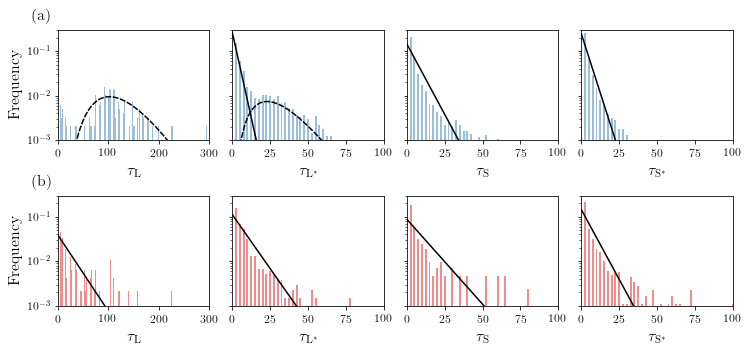

In [17]:
plt.rcParams['figure.figsize'] = (10.5, 5.0)

f, axes = plt.subplots(2, 4, sharey=True, sharex=False)
ax= np.ravel(axes)


labels = ['$\\tau_\mathrm{L}$','$\\tau_{\mathrm{L}^*}$','$\\tau_\mathrm{S}$','$\\tau_{\mathrm{S}^*}$']

i=0
for frame in [zero1_pr43, zero2_pr43, zero3_pr43, zero4_pr43]:
    frame.loc[frame.isrev==True].plot.hist( y=['tau'],alpha=0.5,density=1, linewidth=0., rwidth=0.5, color='#377eb8', bins=bins, ax=ax[i],   logy=True, xlim=(0,100), ylim=(1e-3,0.3), legend=False)
    frame.loc[frame.isrev==False].plot.hist(y=['tau'],alpha=0.5,density=1, linewidth=0., rwidth=0.5, color='#e41a1c', bins=bins, ax=ax[i+4], logy=True, xlim=(0,100), ylim=(1e-3,0.3), legend=False)    
    ax[i].set_xlabel(labels[i])
    ax[i+4].set_xlabel(labels[i])
    i=i+1

i=1
for fit in [s2a_pr43_cr, s3_pr43_cr, s4_pr43_cr, s1_pr43_ec, s2_pr43_ec, s3_pr43_ec, s4_pr43_ec]:
    ax[i].plot(tau,fit,'-k')    
    i=i+1

ax[0].plot(tau,s1_pr43_cr, color='k', linestyle='--', dashes=(4, 1))
ax[1].plot(tau,s2b_pr43_cr, color='k', linestyle='--', dashes=(4, 1))
    
    
ax[0].set_xlim([0,300])    
ax[4].set_xlim([0,300])    

ax[0].text(-50.0, 0.5, '$\\mathrm{(a)}$', fontsize=16)
ax[4].text(-50.0, 0.5, '$\\mathrm{(b)}$', fontsize=16)

plt.tight_layout(rect=[0.0, 0, 1, 0.95]) 
plt.savefig('figures_for_article/figure7.pdf',dpi=300)

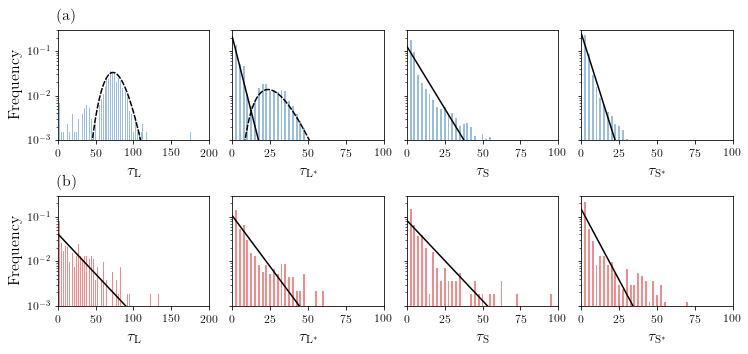

In [18]:
plt.rcParams['figure.figsize'] = (10.5, 5.0)

f, axes = plt.subplots(2, 4, sharey=True, sharex=False)
ax= np.ravel(axes)

labels = ['$\\tau_\mathrm{L}$','$\\tau_{\mathrm{L}^*}$','$\\tau_\mathrm{S}$','$\\tau_{\mathrm{S}^*}$']


i=0
for frame in [zero1_pr3, zero2_pr3, zero3_pr3, zero4_pr3]:
    frame.loc[frame.isrev==True].plot.hist( y=['tau'],alpha=0.5,density=1, linewidth=0., rwidth=0.5, color='#377eb8', bins=bins, ax=ax[i],   logy=True, xlim=(0,100), ylim=(1e-3,0.3), legend=False)
    frame.loc[frame.isrev==False].plot.hist(y=['tau'],alpha=0.5,density=1, linewidth=0., rwidth=0.5, color='#e41a1c', bins=bins, ax=ax[i+4], logy=True, xlim=(0,100), ylim=(1e-3,0.3), legend=False)    
    ax[i].set_xlabel(labels[i])
    ax[i+4].set_xlabel(labels[i])
    i=i+1

i=1
for fit in [s2a_pr3_cr, s3_pr3_cr, s4_pr3_cr, s1_pr3_ec, s2_pr3_ec, s3_pr3_ec, s4_pr3_ec]:
    ax[i].plot(tau,fit,'-k')    
    i=i+1    

ax[0].plot(tau,s1_pr3_cr, color='k', linestyle='--', dashes=(4, 1))
ax[1].plot(tau,s2b_pr3_cr, color='k', linestyle='--', dashes=(4, 1))

ax[0].set_xlim([0,200])    
ax[4].set_xlim([0,200])

ax[0].text(-0.5, 0.5, '$\\mathrm{(a)}$', fontsize=16)
ax[4].text(-0.5, 0.5, '$\\mathrm{(b)}$', fontsize=16)

plt.tight_layout(rect=[0.0, 0, 1, 0.95]) 
plt.savefig('figures_for_article/figure8.pdf',dpi=300)

## 4. Time evolution of POD modes during a generic reversal

First we compute the generic reversal cycle as done in CSR16, but using the amplitude of mode $\mathrm{L}$ instead of the global angular impulse $\mathrm{A_{2D}}$. The steps are the following:

4.1. Apply symmetry operators to time series to increase the number of events

4.2. Identify a set of $n$ time instants at which the amplitude of mode $\mathrm{L}=0$ and the corresponding time interval $\tau_i = t_{i+1} - t_i$

4.3. Separate the CR and EC regimes using the amplitude-based filted of $\mathrm{A_{2D}}$.

4.4. Split the time series of a given quantity $f(t)$ into $n-1$ series defined between $t_o=(t-t_i)/\tau_i$, such that $t_o\in[0,1]$

4.5. Evaluate the same quantity for the interval $t_o\in[-1,1]$

4.6. Finally, we take the average over the ensemble of realizations

In [19]:
def stacking(index_i,index_f,x,y):
    m = index_i.shape[0]
    x1 = np.linspace(0.0, 1.0, num=400)
    y1 = np.zeros((m,400),dtype=float)
    for i in np.arange(m-1):
        x0 = np.linspace(0.0, 1.0, num=index_f[i]-index_i[i])
        y0 = y[index_i[i]:index_f[i]]
        y1[i,:] = np.interp(x1, x0, y0)
        
    y1 = y1.T
    return x1,y1;
    
def generic(t,x,y,z,switch,group,key,flag,thres):
    print(' Evaluating generic cycle for ', key)
# Step 0
    tmax = np.max(t)+0.05
    t = np.concatenate((t,t+tmax,t+2*tmax,t+3*tmax),axis=0)    
    x = np.concatenate((x,-x,-x,x),axis=0)    
    z = np.concatenate((z,-z,-z,z),axis=0)    

    if (group == 1):
        y = np.concatenate((y,-y,-y,y),axis=0)    
    elif (group == 2):
        y = np.concatenate((y,y,y,y),axis=0)    
    elif (group == 3):
        y = np.concatenate((-y,y,-y,y),axis=0)    
    elif (group == 4):
        y = np.concatenate((y,y,-y,-y),axis=0) 

    
    #Step 1
    zero, index = np.array(crossings(t, x, z, 0.))

    #Step 2
    zero['isrev'] = zero['ymax'].abs() > thres
    zero_cr = zero.loc[zero.isrev==True]
    index_i = zero_cr.idxi.values
    index_f = zero_cr.idxf.values

    #Step 3
    ts,xs = stacking(index_i,index_f,t,x)
    ts,ys = stacking(index_i,index_f,t,y)

    #Step 4
    if switch:     
        a = np.max(xs,axis=0)
        b = np.max(-xs,axis=0)
        signs = np.where(a < b,-1,+1)
        ys = ys*signs
        ys = np.concatenate((-ys,ys),axis=0)    
    else:
        ys = np.concatenate((ys,ys),axis=0)    
        
    ts = np.concatenate((ts-1,ts),axis=0) 

    # Step 5
    c = np.shape(ys)   
    YS = ys.T.flatten()
    TS = np.tile(ts,c[1])
    
    ys_mean = np.mean(ys,axis=1)       
    ys_var = np.std(ys,axis=1)   
    
 
    m = index_i.shape[0]
    t0 = np.zeros((10000,m))
    y0 = np.zeros((10000,m))
    c0 = np.zeros((10000,m))
    for n in range(0,m):
        p = index_f[n]-index_i[n]
        a = t[index_i[n]:index_f[n]]
        b = x[index_i[n]:index_f[n]]
        c = y[index_i[n]:index_f[n]]
        
        if switch:     
            d = np.max(b,axis=0)
            e = np.max(-b,axis=0)
            signs = np.where(d < e,-1,+1)
            if(signs==1):
                t0[0:p,n] = a[0:p]-t[index_i[n]]
                y0[0:p,n] = c[0:p]                
            else:
                t0[0:p,n] = a[0:p]-t[index_f[n]]
                y0[0:p,n] = c[0:p]
                
        c0[0:p,n] = n*np.ones((p,))
    
    t0 = t0.T.flatten()/zero_cr.tau.mean()
    y0 = y0.T.flatten()
    c0 = c0.T.flatten()
    
    if flag:
        ys_collapsed = pd.DataFrame({'t':ts,key+'mean':ys_mean,key+'var':ys_var})
        YS_collapsed = pd.DataFrame({'t':TS,key:YS})    
        YS_stacked = pd.DataFrame({'t':t0, 'rev': c0, key:y0})    
    else:
        ys_collapsed = pd.DataFrame({key+'mean':ys_mean,key+'var':ys_var})
        YS_collapsed = pd.DataFrame({key:YS})      
        YS_stacked = pd.DataFrame({'rev': c0, key:y0})    
    
    return ys_collapsed, YS_collapsed;

In [20]:
cycle_k1_pr43, stacked_k1_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k1'], glb_pr43['l2d'], True,  1, 'k1', True,  thres_pr43)
cycle_k2_pr43, stacked_k2_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k2'], glb_pr43['l2d'], False, 2, 'k2', False, thres_pr43)
cycle_k3_pr43, stacked_k3_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k4'], glb_pr43['l2d'], True,  1, 'k3', False, thres_pr43)
cycle_k4_pr43, stacked_k4_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k3'], glb_pr43['l2d'], False, 3, 'k4', False, thres_pr43)
cycle_k5_pr43, stacked_k5_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k5'], glb_pr43['l2d'], False, 2, 'k5', False, thres_pr43)
cycle_k6_pr43, stacked_k6_pr43 =  generic(pod_pr43['t'], pod_pr43['k1'], pod_pr43['k6'], glb_pr43['l2d'], False, 4, 'k6', False, thres_pr43)

scale1 = glb_pr43['l2d'].abs().mean()
scale2 = 1 #glb_pr43['ekin'].mean()
scale3 = glb_pr43['m2d'].abs().mean()
scale4 = (nus_pr43['vol'].abs().mean() + nus_pr43['top'].abs().mean() + nus_pr43['bot'].abs().mean())/3.
cycle_l2d_pr43,  stacked_l2d_pr43  = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['l2d']/scale1,  glb_pr43['l2d'], True,  1,'l2d',  False, thres_pr43)
cycle_ekin_pr43, stacked_ekin_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['ekin']/scale2, glb_pr43['l2d'], False, 2,'ekin', False, thres_pr43)
cycle_apot_pr43, stacked_apot_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['apot']/scale2, glb_pr43['l2d'], False, 2,'apot', False, thres_pr43)

cycle_m2d_pr43,  stacked_m2d_pr43  = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['m2d']/scale3,  glb_pr43['l2d'], True, 1,'m2d',  False, thres_pr43)
cycle_ia2d_pr43, stacked_ia2d_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['ia2d']/scale3, glb_pr43['l2d'], True, 1,'ia2d', False, thres_pr43)
cycle_ib2d_pr43, stacked_ib2d_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['ib2d']/scale3, glb_pr43['l2d'], True, 1,'ib2d', False, thres_pr43)

cycle_nuvol_pr43, stacked_nuvol_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], nus_pr43['vol']/scale4, glb_pr43['l2d'], False, 2,'nuvol', False, thres_pr43)
cycle_nubot_pr43, stacked_nubot_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], nus_pr43['bot']/scale4, glb_pr43['l2d'], False, 2,'nubot', False, thres_pr43)
cycle_nutop_pr43, stacked_nutop_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], nus_pr43['top']/scale4, glb_pr43['l2d'], False, 2,'nutop', False, thres_pr43)

cycle_epsu_pr43, stacked_epsu_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], nus_pr43['epsu']/scale4, glb_pr43['l2d'], False, 2,'epsu', False, thres_pr43)
cycle_epst_pr43, stacked_epst_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], nus_pr43['epst']/scale4, glb_pr43['l2d'], False, 2,'epst', False, thres_pr43)
cycle_phid_pr43, stacked_phid_pr43 = generic(pod_pr43['t'], pod_pr43['k1'], glb_pr43['phid']/scale4, glb_pr43['l2d'], False, 2,'phid', False, thres_pr43)

cycle_pr43 = pd.concat([cycle_k1_pr43, cycle_k2_pr43, cycle_k3_pr43, cycle_k4_pr43, cycle_k5_pr43, cycle_k6_pr43, 
                       cycle_l2d_pr43, cycle_ekin_pr43, cycle_apot_pr43, -1*cycle_m2d_pr43, cycle_ia2d_pr43, -1*cycle_ib2d_pr43,
                       cycle_nuvol_pr43, -1*cycle_nubot_pr43, -1*cycle_nutop_pr43, cycle_epsu_pr43, cycle_epst_pr43, cycle_phid_pr43], axis=1)#, sort=False)
stacked_pr43 = pd.concat([stacked_k1_pr43, stacked_k2_pr43, stacked_k3_pr43, stacked_k4_pr43, stacked_k5_pr43, stacked_k6_pr43, 
                         stacked_l2d_pr43, stacked_ekin_pr43, stacked_apot_pr43, -1*stacked_m2d_pr43, stacked_ia2d_pr43, -1*stacked_ib2d_pr43,
                         stacked_nuvol_pr43, -1*stacked_nubot_pr43, -1*stacked_nutop_pr43, stacked_epsu_pr43, stacked_epst_pr43, stacked_phid_pr43], axis=1)#, sort=False)


 Evaluating generic cycle for  k1
 Evaluating generic cycle for  k2
 Evaluating generic cycle for  k3
 Evaluating generic cycle for  k4
 Evaluating generic cycle for  k5
 Evaluating generic cycle for  k6
 Evaluating generic cycle for  l2d
 Evaluating generic cycle for  ekin
 Evaluating generic cycle for  apot
 Evaluating generic cycle for  m2d
 Evaluating generic cycle for  ia2d
 Evaluating generic cycle for  ib2d
 Evaluating generic cycle for  nuvol
 Evaluating generic cycle for  nubot
 Evaluating generic cycle for  nutop
 Evaluating generic cycle for  epsu
 Evaluating generic cycle for  epst
 Evaluating generic cycle for  phid


In [21]:
cycle_k1_pr3, stacked_k1_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k1'], glb_pr3['l2d'], True,  1, 'k1', True,  thres_pr3)
cycle_k2_pr3, stacked_k2_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k2'], glb_pr3['l2d'], False, 2, 'k2', False, thres_pr3)
cycle_k3_pr3, stacked_k3_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k3'], glb_pr3['l2d'], True,  1, 'k3', False, thres_pr3)
cycle_k4_pr3, stacked_k4_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k4'], glb_pr3['l2d'], False, 3, 'k4', False, thres_pr3)
cycle_k5_pr3, stacked_k5_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k5'], glb_pr3['l2d'], False, 2, 'k5', False, thres_pr3)
cycle_k6_pr3, stacked_k6_pr3 =  generic(pod_pr3['t'], pod_pr3['k1'], pod_pr3['k6'], glb_pr3['l2d'], False, 4, 'k6', False, thres_pr3)

scale1 = glb_pr3['l2d'].abs().mean()
scale2 = 1 #glb_pr3['ekin'].mean()
scale3 = glb_pr3['m2d'].abs().mean()
cycle_l2d_pr3,  stacked_l2d_pr3  = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['l2d']/scale1,  glb_pr3['l2d'], True,  1,'l2d',  False, thres_pr3)
cycle_ekin_pr3, stacked_ekin_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['ekin']/scale2, glb_pr3['l2d'], False, 2,'ekin', False, thres_pr3)
cycle_apot_pr3, stacked_apot_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['apot']/scale2, glb_pr3['l2d'], False, 2,'apot', False, thres_pr3)

cycle_m2d_pr3,  stacked_m2d_pr3  = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['m2d']/scale3,  glb_pr3['l2d'], True, 1,'m2d',  False, thres_pr3)
cycle_ia2d_pr3, stacked_ia2d_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['ia2d']/scale3, glb_pr3['l2d'], True, 1,'ia2d', False, thres_pr3)
cycle_ib2d_pr3, stacked_ib2d_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['ib2d']/scale3, glb_pr3['l2d'], True, 1,'ib2d', False, thres_pr3)

cycle_nuvol_pr3, stacked_nuvol_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], nus_pr3['vol']/scale4, glb_pr3['l2d'], False, 2,'nuvol', False, thres_pr3)
cycle_nubot_pr3, stacked_nubot_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], nus_pr3['bot']/scale4, glb_pr3['l2d'], False, 2,'nubot', False, thres_pr3)
cycle_nutop_pr3, stacked_nutop_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], nus_pr3['top']/scale4, glb_pr3['l2d'], False, 2,'nutop', False, thres_pr3)

cycle_epsu_pr3, stacked_epsu_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], nus_pr3['epsu']/scale4, glb_pr3['l2d'], False, 2,'epsu', False, thres_pr3)
cycle_epst_pr3, stacked_epst_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], nus_pr3['epst']/scale4, glb_pr3['l2d'], False, 2,'epst', False, thres_pr3)
cycle_phid_pr3, stacked_phid_pr3 = generic(pod_pr3['t'], pod_pr3['k1'], glb_pr3['phid']/scale4, glb_pr3['l2d'], False, 2,'phid', False, thres_pr3)

cycle_pr3 = pd.concat([cycle_k1_pr3, cycle_k2_pr3, cycle_k3_pr3, cycle_k4_pr3, cycle_k5_pr3, cycle_k6_pr3, 
                       cycle_l2d_pr3, cycle_ekin_pr3, cycle_apot_pr3, -1*cycle_m2d_pr3, cycle_ia2d_pr3, -1*cycle_ib2d_pr3,
                       cycle_nuvol_pr3, -1*cycle_nubot_pr3, -1*cycle_nutop_pr3, cycle_epsu_pr3, cycle_epst_pr3, cycle_phid_pr3], axis=1)#, sort=False)
stacked_pr3 = pd.concat([stacked_k1_pr3, stacked_k2_pr3, stacked_k3_pr3, stacked_k4_pr3, stacked_k5_pr3, stacked_k6_pr3, 
                         stacked_l2d_pr3, stacked_ekin_pr3, stacked_apot_pr3, -1*stacked_m2d_pr3, stacked_ia2d_pr3, -1*stacked_ib2d_pr3, 
                         stacked_nuvol_pr3, -1*stacked_nubot_pr3, -1*stacked_nutop_pr3, stacked_epsu_pr3, stacked_epst_pr3, stacked_phid_pr3], axis=1)#, sort=False)

 Evaluating generic cycle for  k1
 Evaluating generic cycle for  k2
 Evaluating generic cycle for  k3
 Evaluating generic cycle for  k4
 Evaluating generic cycle for  k5
 Evaluating generic cycle for  k6
 Evaluating generic cycle for  l2d
 Evaluating generic cycle for  ekin
 Evaluating generic cycle for  apot
 Evaluating generic cycle for  m2d
 Evaluating generic cycle for  ia2d
 Evaluating generic cycle for  ib2d
 Evaluating generic cycle for  nuvol
 Evaluating generic cycle for  nubot
 Evaluating generic cycle for  nutop
 Evaluating generic cycle for  epsu
 Evaluating generic cycle for  epst
 Evaluating generic cycle for  phid


### First, we plot the generic reversal cycle (figure 9)

In [22]:
plt.rcParams['figure.figsize'] = (10.5, 6.25)

from matplotlib.colors import LogNorm

import matplotlib as mpl
cmap0 = mpl.cm.Greys
cmap1 = mpl.cm.Blues
cmap2 = mpl.cm.Greens
cmap3 = mpl.cm.Oranges

cmap1.set_bad('white',1.)
cmap2.set_bad('white',1.)
cmap3.set_bad('white',1.)


from matplotlib.ticker import MultipleLocator, FormatStrFormatter
def generic_cycle (x,y,x2,y2,y3,a,b,c,vmin,vmax,ax):


    
    ranges=[[-1.0, 1.0], [vmin, vmax]]
    ranges_aa=[[-1.0, -1.0+a], [vmin, vmax]]
    ranges_ba=[[-1.0+a, -1.0+a+b], [vmin, vmax]]
    ranges_ca=[[-1.0+a+b, 0.0], [vmin, vmax]]
    ranges_ab=[[0, a], [vmin, vmax]]
    ranges_bb=[[a, a+b], [vmin, vmax]]
    ranges_cb=[[a+b, 1.0], [vmin, vmax]]
    
    scale = y.size    
    hist, xedges, yedges = np.histogram2d(x,y,bins=[400,400], range=ranges, normed=True)
    
    hist_aa, xedges_aa, yedges_aa = np.histogram2d(x,y,bins=[a*400,400], range=ranges_aa, normed=False)
    hist_ba, xedges_ba, yedges_ba = np.histogram2d(x,y,bins=[b*400,400], range=ranges_ba, normed=False)
    hist_ca, xedges_ca, yedges_ca = np.histogram2d(x,y,bins=[c*400,400], range=ranges_ca, normed=False)
    hist_ab, xedges_ab, yedges_ab = np.histogram2d(x,y,bins=[a*400,400], range=ranges_ab, normed=False)
    hist_bb, xedges_bb, yedges_bb = np.histogram2d(x,y,bins=[b*400,400], range=ranges_bb, normed=False)
    hist_cb, xedges_cb, yedges_cb = np.histogram2d(x,y,bins=[c*400,400], range=ranges_cb, normed=False)

    cmin=1
    cmax=100
    im = ax.imshow(hist.T, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap=cmap1,norm=LogNorm(vmin=cmin,vmax=cmax), rasterized=True)
    
    ax.imshow(hist_aa.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_aa[0], xedges_aa[-1], yedges_aa[0], yedges_aa[-1]], cmap=cmap3,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)
    ax.imshow(hist_ba.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_ba[0], xedges_ba[-1], yedges_ba[0], yedges_ba[-1]], cmap=cmap2,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)
    ax.imshow(hist_ca.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_ca[0], xedges_ca[-1], yedges_ca[0], yedges_ca[-1]], cmap=cmap1,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)

    ax.imshow(hist_ab.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_ab[0], xedges_ab[-1], yedges_ab[0], yedges_ab[-1]], cmap=cmap3,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)
    ax.imshow(hist_bb.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_bb[0], xedges_bb[-1], yedges_bb[0], yedges_bb[-1]], cmap=cmap2,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)
    ax.imshow(hist_cb.T/scale, interpolation='bilinear', aspect='auto', origin='low', extent=[xedges_cb[0], xedges_cb[-1], yedges_cb[0], yedges_cb[-1]], cmap=cmap1,norm=LogNorm(vmin=cmin/scale,vmax=cmax/scale), rasterized=True)

    ax.plot(x2,y2,'-k', rasterized=True)
    ax.plot(x2,x2*0.,'-r',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
    ax.plot(x2,y2+y3,color='black', linestyle='--', dashes=(5, 2), linewidth=0.75, rasterized=True)
    ax.plot(x2,y2-y3,color='black', linestyle='--', dashes=(5, 2), linewidth=0.75, rasterized=True)
    ax.plot(0,y2[np.min(np.where(x2==0))],'ok',markersize=8, rasterized=True)
    ax.plot(0,y2[np.min(np.where(x2==0))],'ow',markersize=5, rasterized=True)
    
    #from mpl_toolkits.axes_grid1 import make_axes_locatable
    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes('right', size='2.5%', pad=0.05)
    plt.colorbar(im, ax=ax, orientation='vertical');
    
    majorLocator = MultipleLocator(1.0)
    ax.xaxis.set_major_locator(majorLocator)
    minorLocator = MultipleLocator(0.05)
    ax.xaxis.set_minor_locator(minorLocator)
    majorLocator = MultipleLocator(1.0)
    ax.yaxis.set_major_locator(majorLocator)
    minorLocator = MultipleLocator(0.1)
    ax.yaxis.set_minor_locator(minorLocator)



    return im

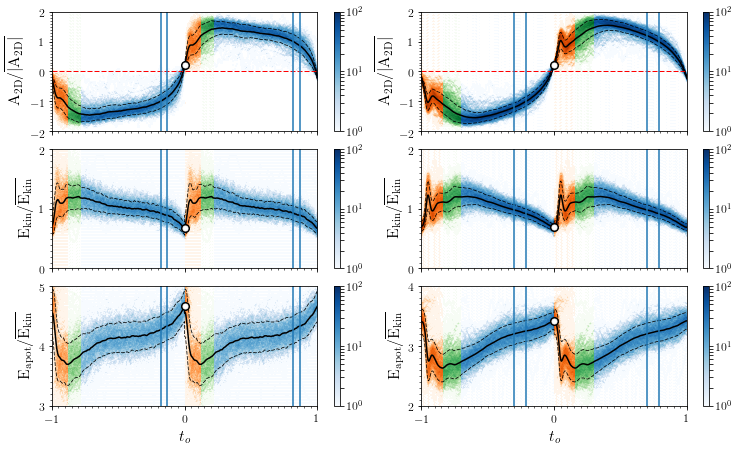

In [23]:
plt.rcParams['figure.figsize'] = (10.5, 6.25)

f, axes = plt.subplots(3, 2, sharey=False, sharex=True)
ax= np.ravel(axes)

ranges1=[[-1.0, 1.0], [-2.0, 2.0]]
ranges2=[[-1.0, 1.0], [0.0, 5.0]]

generic_cycle (stacked_pr43.t, stacked_pr43.l2d,cycle_pr43.t,  cycle_pr43.l2dmean,  cycle_pr43.l2dvar,  0.12,0.10,0.78,-2.5,2.5, ax[0])
generic_cycle (stacked_pr43.t, stacked_pr43.ekin,cycle_pr43.t, cycle_pr43.ekinmean, cycle_pr43.ekinvar, 0.12,0.10,0.78,0,2, ax[2])
generic_cycle (stacked_pr43.t, stacked_pr43.apot,cycle_pr43.t, cycle_pr43.apotmean, cycle_pr43.apotvar, 0.12,0.10,0.78,3.0,5.0, ax[4])

generic_cycle (stacked_pr3.t, stacked_pr3.l2d,  cycle_pr3.t, cycle_pr3.l2dmean,  cycle_pr3.l2dvar,  0.16,0.14,0.70,-2.5,2.5, ax[1])
generic_cycle (stacked_pr3.t, stacked_pr3.ekin, cycle_pr3.t, cycle_pr3.ekinmean, cycle_pr3.ekinvar, 0.16,0.14,0.70,0,2, ax[3])
generic_cycle (stacked_pr3.t, stacked_pr3.apot, cycle_pr3.t, cycle_pr3.apotmean, cycle_pr3.apotvar, 0.16,0.14,0.70,2,4, ax[5])

labels = ['$ \mathrm{A_{2D}}/\overline{\\vert \mathrm{A_{2D}} \\vert}  $', 
          '$ \mathrm{E_{kin}}/\overline{\mathrm{E_{kin}}}  $', 
          '$ \mathrm{E_{apot}}/\overline{\mathrm{E_{kin}}}  $']
i=0
for label in labels:
    ax[2*i].set_ylabel(label)
    xcoords = [-1+0.82, -1+0.87, 0.82, 0.87]
    for xc in xcoords:
        ax[2*i].axvline(x=xc)    
    i=i+1

i=0
for label in labels:
    ax[2*i+1].set_ylabel(label)
    xcoords = [-1+0.7, -1+0.79, 0.7, 0.79]
    for xc in xcoords:
        ax[2*i+1].axvline(x=xc)    
    i=i+1

ax[0].set_ylim([-2.0,2.0])
ax[2].set_ylim([0.0,2.0])
ax[4].set_ylim([3,5])

ax[1].set_ylim([-2.0,2.0])
ax[3].set_ylim([0.0,2.0])
ax[5].set_ylim([2.0,4.0])

ax[4].set_xlabel('$ t_o $')
ax[5].set_xlabel('$ t_o $')

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure9.pdf',dpi=300)

### Then, we plot the modal coefficients during a generic reversal (figures 10 and 11)

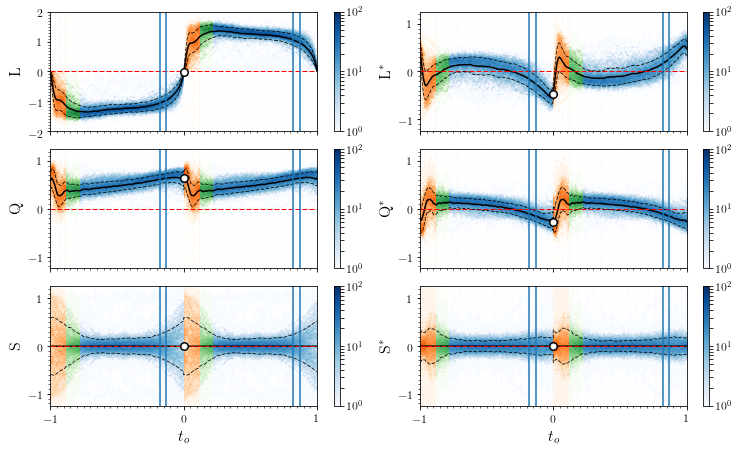

In [24]:
plt.rcParams['figure.figsize'] = (10.5, 6.25)
f, axes = plt.subplots(3, 2, sharey=False, sharex=True)
ax= np.ravel(axes)

ranges1=[[-1.0, 1.0], [-2.0, 2.0]]
ranges2=[[-1.0, 1.0], [0.0, 5.0]]

generic_cycle (stacked_pr43.t, stacked_pr43.k1, cycle_pr43.t, cycle_pr43.k1mean, cycle_pr43.k1var, 0.12,0.10,0.78,-2.0,2.0, ax[0])
generic_cycle (stacked_pr43.t, stacked_pr43.k2, cycle_pr43.t, cycle_pr43.k2mean, cycle_pr43.k2var, 0.12,0.10,0.78,-1.25,1.25, ax[2])
generic_cycle (stacked_pr43.t, stacked_pr43.k4, cycle_pr43.t, cycle_pr43.k4mean, cycle_pr43.k4var, 0.12,0.10,0.78,-1.25,1.25, ax[4])

generic_cycle (stacked_pr43.t, stacked_pr43.k3, cycle_pr43.t, cycle_pr43.k3mean, cycle_pr43.k3var, 0.12,0.10,0.78,-1.25,1.25, ax[1])
generic_cycle (stacked_pr43.t, stacked_pr43.k5, cycle_pr43.t, cycle_pr43.k5mean, cycle_pr43.k5var, 0.12,0.10,0.78,-1.25,1.25, ax[3])
generic_cycle (stacked_pr43.t, stacked_pr43.k6, cycle_pr43.t, cycle_pr43.k6mean, cycle_pr43.k6var, 0.12,0.10,0.78,-1.25,1.25, ax[5])

labels = ['$\mathrm{L}$','$\mathrm{L^*}$','$\mathrm{Q}$','$\mathrm{Q^*}$','$\mathrm{S}$','$\mathrm{S^*}$']
i=0
for label in labels:
    ax[i].set_ylabel(label)
    xcoords = [-1+0.82, -1+0.87, 0.82, 0.87]
    for xc in xcoords:
        ax[i].axvline(x=xc)    
    i=i+1

ax[4].set_xlabel('$ t_o $')
ax[5].set_xlabel('$ t_o $')

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure10.pdf',dpi=300)

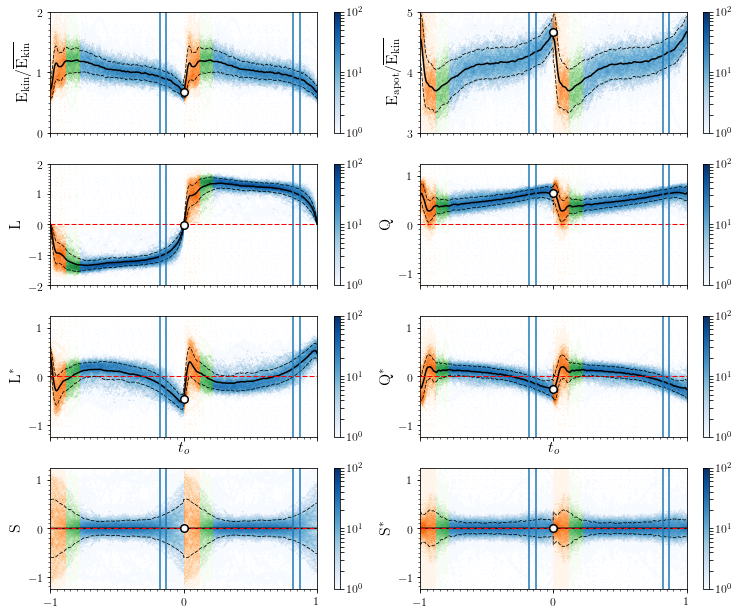

In [25]:
plt.rcParams['figure.figsize'] = (10.5, 8.5)
f, axes = plt.subplots(4, 2, sharey=False, sharex=True)
ax= np.ravel(axes)

ranges1=[[-1.0, 1.0], [-2.0, 2.0]]
ranges2=[[-1.0, 1.0], [0.0, 5.0]]

generic_cycle (stacked_pr43.t, stacked_pr43.ekin,cycle_pr43.t, cycle_pr43.ekinmean, cycle_pr43.ekinvar, 0.12,0.10,0.78,0,2,     ax[0])
generic_cycle (stacked_pr43.t, stacked_pr43.apot,cycle_pr43.t, cycle_pr43.apotmean, cycle_pr43.apotvar, 0.12,0.10,0.78,3.0,5.0, ax[1])

generic_cycle (stacked_pr43.t, stacked_pr43.k1, cycle_pr43.t, cycle_pr43.k1mean, cycle_pr43.k1var, 0.12,0.10,0.78,-2.0,2.0,   ax[2])
generic_cycle (stacked_pr43.t, stacked_pr43.k2, cycle_pr43.t, cycle_pr43.k2mean, cycle_pr43.k2var, 0.12,0.10,0.78,-1.25,1.25, ax[3])
generic_cycle (stacked_pr43.t, stacked_pr43.k3, cycle_pr43.t, cycle_pr43.k3mean, cycle_pr43.k3var, 0.12,0.10,0.78,-1.25,1.25, ax[4])
generic_cycle (stacked_pr43.t, stacked_pr43.k5, cycle_pr43.t, cycle_pr43.k5mean, cycle_pr43.k5var, 0.12,0.10,0.78,-1.25,1.25, ax[5])
generic_cycle (stacked_pr43.t, stacked_pr43.k4, cycle_pr43.t, cycle_pr43.k4mean, cycle_pr43.k4var, 0.12,0.10,0.78,-1.25,1.25, ax[6])
generic_cycle (stacked_pr43.t, stacked_pr43.k6, cycle_pr43.t, cycle_pr43.k6mean, cycle_pr43.k6var, 0.12,0.10,0.78,-1.25,1.25, ax[7])

labels = ['$ \mathrm{E_{kin}}/\overline{\mathrm{E_{kin}}}  $', '$ \mathrm{E_{apot}}/\overline{\mathrm{E_{kin}}}  $', 
          '$\mathrm{L}$','$\mathrm{Q}$','$\mathrm{L^*}$','$\mathrm{Q^*}$','$\mathrm{S}$','$\mathrm{S^*}$']

i=0
for label in labels:
    ax[i].set_ylabel(label)
    xcoords = [-1+0.82, -1+0.87, 0.82, 0.87]
    for xc in xcoords:
        ax[i].axvline(x=xc)    
    i=i+1

ax[4].set_xlabel('$ t_o $')
ax[5].set_xlabel('$ t_o $')

ax[1].set_ylim([3.0,5.0])

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure10.pdf',dpi=300)

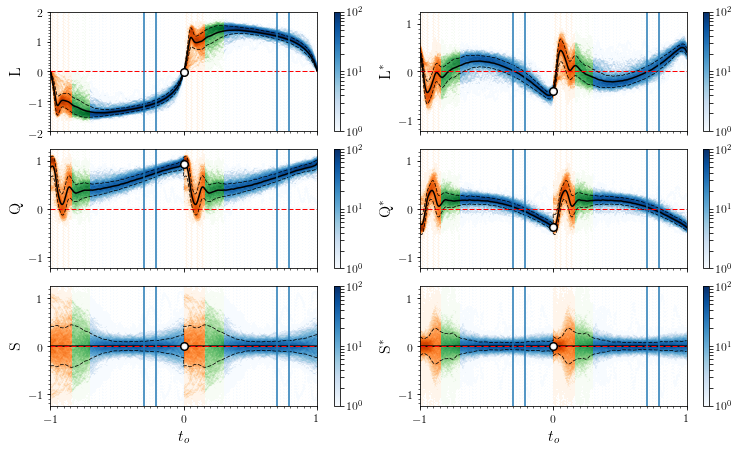

In [26]:
plt.rcParams['figure.figsize'] = (10.5, 6.25)
f, axes = plt.subplots(3, 2, sharey=False, sharex=True)
ax= np.ravel(axes)

ranges1=[[-1.0, 1.0], [-2.0, 2.0]]
ranges2=[[-1.0, 1.0], [0.0, 5.0]]

generic_cycle (stacked_pr3.t, stacked_pr3.k1, cycle_pr3.t, cycle_pr3.k1mean, cycle_pr3.k1var, 0.16,0.14,0.70,-2.0,2.0, ax[0])
generic_cycle (stacked_pr3.t, stacked_pr3.k2, cycle_pr3.t, cycle_pr3.k2mean, cycle_pr3.k2var, 0.16,0.14,0.70,-1.25,1.25, ax[2])
generic_cycle (stacked_pr3.t, stacked_pr3.k4, cycle_pr3.t, cycle_pr3.k4mean, cycle_pr3.k4var, 0.16,0.14,0.70,-1.25,1.25, ax[4])

generic_cycle (stacked_pr3.t, stacked_pr3.k3, cycle_pr3.t, cycle_pr3.k3mean, cycle_pr3.k3var, 0.16,0.14,0.70,-1.25,1.25, ax[1])
generic_cycle (stacked_pr3.t, stacked_pr3.k5, cycle_pr3.t, cycle_pr3.k5mean, cycle_pr3.k5var, 0.16,0.14,0.70,-1.25,1.25, ax[3])
generic_cycle (stacked_pr3.t, stacked_pr3.k6, cycle_pr3.t, cycle_pr3.k6mean, cycle_pr3.k6var, 0.16,0.14,0.70,-1.25,1.25, ax[5])

labels = ['$\mathrm{L}$','$\mathrm{L^*}$','$\mathrm{Q}$','$\mathrm{Q^*}$','$\mathrm{S}$','$\mathrm{S^*}$']
i=0
for label in labels:
    ax[i].set_ylabel(label)
    xcoords = [-1+0.7, -1+0.79, 0.7, 0.79]
    for xc in xcoords:
        ax[i].axvline(x=xc)    
    i=i+1

ax[4].set_xlabel('$ t_o $')
ax[5].set_xlabel('$ t_o $')

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure11.pdf',dpi=300)

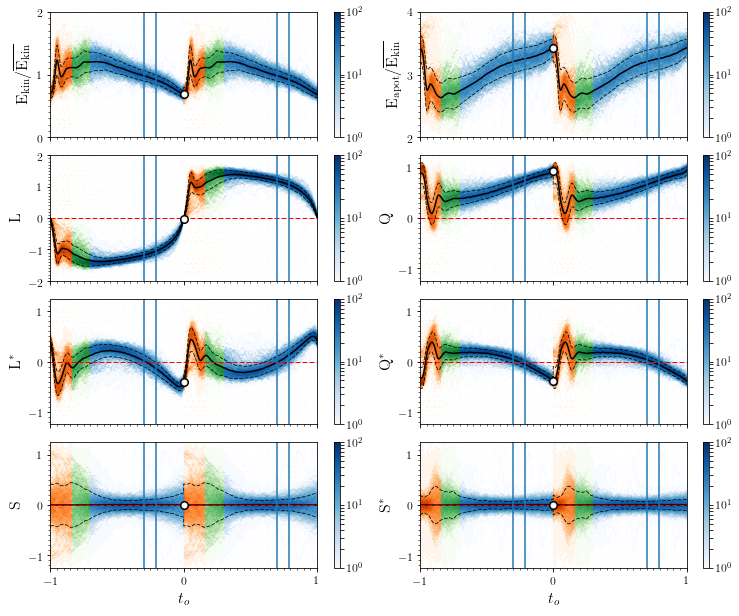

In [27]:
plt.rcParams['figure.figsize'] = (10.5, 8.5)
f, axes = plt.subplots(4, 2, sharey=False, sharex=True)
ax= np.ravel(axes)

ranges1=[[-1.0, 1.0], [-2.0, 2.0]]
ranges2=[[-1.0, 1.0], [0.0, 5.0]]

generic_cycle (stacked_pr3.t, stacked_pr3.ekin, cycle_pr3.t, cycle_pr3.ekinmean, cycle_pr3.ekinvar, 0.16,0.14,0.70,0,2, ax[0])
generic_cycle (stacked_pr3.t, stacked_pr3.apot, cycle_pr3.t, cycle_pr3.apotmean, cycle_pr3.apotvar, 0.16,0.14,0.70,2,4, ax[1])

generic_cycle (stacked_pr3.t, stacked_pr3.k1, cycle_pr3.t, cycle_pr3.k1mean, cycle_pr3.k1var, 0.16,0.14,0.70,-2.0,2.0,   ax[2])
generic_cycle (stacked_pr3.t, stacked_pr3.k2, cycle_pr3.t, cycle_pr3.k2mean, cycle_pr3.k2var, 0.16,0.14,0.70,-1.25,1.25, ax[3])
generic_cycle (stacked_pr3.t, stacked_pr3.k3, cycle_pr3.t, cycle_pr3.k3mean, cycle_pr3.k3var, 0.16,0.14,0.70,-1.25,1.25, ax[4])
generic_cycle (stacked_pr3.t, stacked_pr3.k5, cycle_pr3.t, cycle_pr3.k5mean, cycle_pr3.k5var, 0.16,0.14,0.70,-1.25,1.25, ax[5])
generic_cycle (stacked_pr3.t, stacked_pr3.k4, cycle_pr3.t, cycle_pr3.k4mean, cycle_pr3.k4var, 0.16,0.14,0.70,-1.25,1.25, ax[6])
generic_cycle (stacked_pr3.t, stacked_pr3.k6, cycle_pr3.t, cycle_pr3.k6mean, cycle_pr3.k6var, 0.16,0.14,0.70,-1.25,1.25, ax[7])

labels = ['$ \mathrm{E_{kin}}/\overline{\mathrm{E_{kin}}}  $', '$ \mathrm{E_{apot}}/\overline{\mathrm{E_{kin}}}  $', 
          '$\mathrm{L}$','$\mathrm{Q}$','$\mathrm{L^*}$','$\mathrm{Q^*}$','$\mathrm{S}$','$\mathrm{S^*}$']
i=0
for label in labels:
    ax[i].set_ylabel(label)
    xcoords = [-1+0.7, -1+0.79, 0.7, 0.79]
    for xc in xcoords:
        ax[i].axvline(x=xc)    
    i=i+1

ax[6].set_xlabel('$ t_o $')
ax[7].set_xlabel('$ t_o $')

ax[1].set_ylim([2.0,4.0])

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure11.pdf',dpi=300)

## 5. We save the generic modal coefficients to be used in the other routines

In [28]:
import pickle

filename_pr3 = './results_from_generic_reversal/generic_cycle_pr3.sav'
pickle.dump(cycle_pr3, open(filename_pr3, 'wb'))

filename_pr43 = './results_from_generic_reversal/generic_cycle_pr43.sav'
pickle.dump(cycle_pr43, open(filename_pr43, 'wb'))

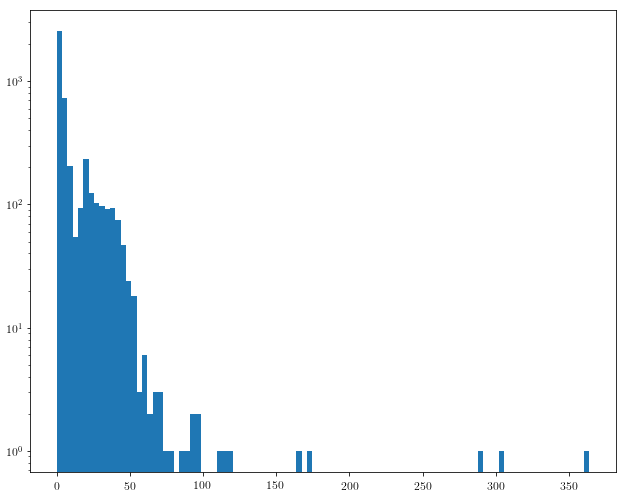

In [60]:
def crossings(x,y,z,c):
    x0 = pd.DataFrame() 
   
    n = y.shape[0]
    index = np.where((y[0:n-2]-c)*(y[1:n-1]-c) < 0)
    index = np.asarray(index)
    index = index.T[:,0]
    m = index.shape[0]
    
    x0['ti'] = x[index.T[0:m-1]]
    x0['tm'] = 0.5*(x[index.T[0:m-1]] + x[index.T[1:m]])
    x0['tf'] = x[index.T[1:m]]
    x0['tau'] = x0['tf'] - x0['ti']
    midpoint = (index.T[1:m]-index.T[0:m-1])/2 + index.T[0:m-1]    
    x0['tm'] = x[midpoint.astype(int)]    
    
    x0['idxi'] = index.T[0:m-1]
    x0['idxf'] = index.T[1:m]
    
    c = np.zeros((m-1,))    
    d = np.zeros((m-1,))    
    for n in range(0, m-1):
        a = np.max(z[np.arange(index.T[n],index.T[n+1])])
        b = np.min(z[np.arange(index.T[n],index.T[n+1])])
        c[n] = a if a>-b else b        
        d[n] = b
        
    x0['ymax'] = c - d
    return x0, index.T;

zero1_pr3, _ = np.array(crossings(pod_pr3.t.values, pod_pr3.k5.values, glb_pr3.ekin.values,0.))

plt.hist(zero1_pr3.tau, 100, log=True)
plt.show()